In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook EnMAP - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [2]:
import time
import os

import sys, random, re

import torch; import torch.nn as nn; import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import rasterio as rio; from rasterio.plot import reshape_as_image, reshape_as_raster
import numpy as np; import pandas as pd
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans; from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
import matplotlib.pyplot as plt; import matplotlib.colors as colors; from matplotlib.colors import ListedColormap
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster; from kneed import KneeLocator
import xml.etree.ElementTree as ET
from tqdm import tqdm
from sklearn.manifold import TSNE
import seaborn as sns

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the EnMAP image and display them.

In [3]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read()).astype(np.float32) 

    arr_img = np.clip(arr_img, 0, 1)

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_2d = (mask_band > 0)
    mask_flat = mask_2d.ravel()

    X = image.reshape(l, -1).T
    pixels_interest = X[mask_flat]

    scaler = StandardScaler()
    scaled = scaler.fit_transform(pixels_interest)

    # On crée un tableau de zéros et on y injecte les pixels scalés
    # Le fond reste à 0.0 (la moyenne exacte de la végétation)
    X_scaled_flat = np.zeros_like(X)
    X_scaled_flat[mask_flat] = scaled

    # On remet l'image en 3D (m, n, l)
    X_scaled = X_scaled_flat.reshape(m, n, l)

    # --- 4. Préparation RGB pour affichage ---
    # On sélectionne les bandes R (2), G (1), B (0)
    rgb = X_scaled[:, :, [2, 1, 0]]

    # Calcul des min/max uniquement sur la zone d'intérêt pour un bon contraste
    # On utilise des percentiles ou un min/max localisé
    rgb_veg_only = rgb[mask_2d]
    min_val = np.nanmin(rgb_veg_only, axis=0)
    max_val = np.nanmax(rgb_veg_only, axis=0)
    
    # Normalisation 0-1 pour imshow
    rgb_norm = (rgb - min_val) / (max_val - min_val + 1e-8)
    
    # Forcer le fond en noir pur (Correction de la variable mask -> mask_band)
    fond_bool = (mask_band == 0)
    rgb_norm[fond_bool] = 0.0
    
    # Sécurité pour l'affichage
    rgb_norm = np.clip(rgb_norm, 0, 1)

    # --- 5. Affichage ---
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_norm)
    plt.title("Visualisation Standardisée (Végétation/Sol)")
    plt.axis('off')
    plt.show()

    return X_scaled, fond_bool

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the soil:

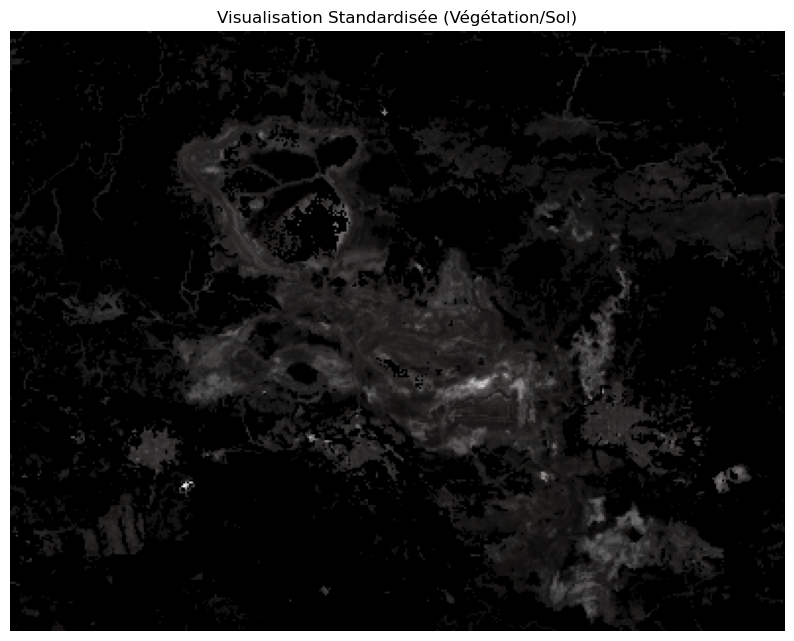

In [4]:
soil_only, fond_soil = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                       r"./INSA_cropped_2_EnMAP_20240508_mask_SOIL_SAVI_DSBI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

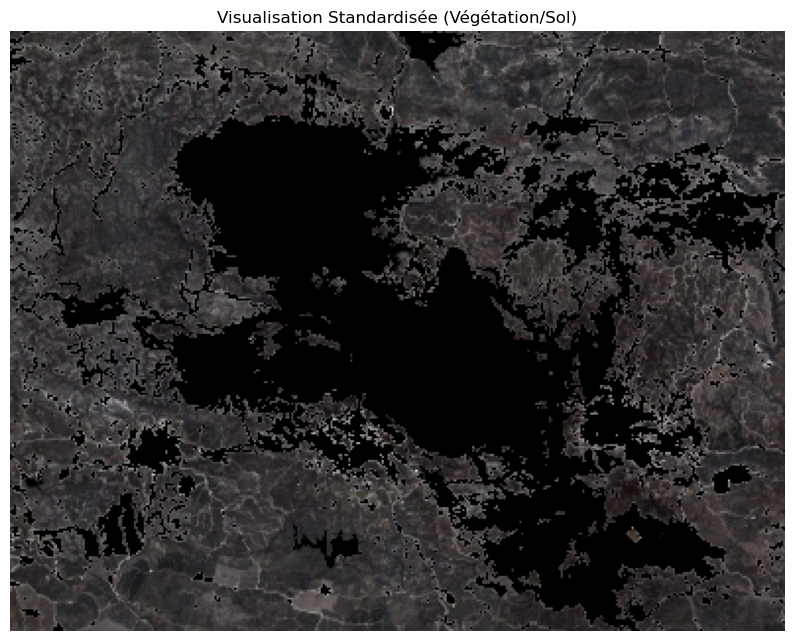

In [5]:
vegetation_only, fond_vegetation = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                             r"./INSA_cropped_2_EnMAP_20240508_mask_NDVI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [6]:
image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = veg_pixels

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation

In [7]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

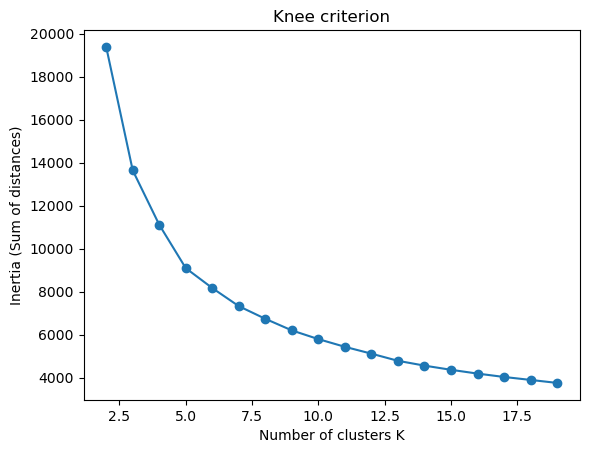

optimal value: k = 6


In [8]:
optimal_k_veg = compute_optimal_k(veg_pixels)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We use the function extract_wavelengths_from_auxxml to get the number of wavelengths and their values.

In [9]:
def extract_wavelengths_from_auxxml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    wavelengths = []

    # Pour chaque bande dans l'ordre
    for band in root.findall(".//PAMRasterBand"):
        desc = band.find("Description")
        if desc is not None and desc.text:
            match = re.search(r"\(([\d.]+)\s*Nanometers\)", desc.text)
            if match:
                wl = float(match.group(1))
                wavelengths.append(wl)

    return wavelengths

In [10]:
xml_file = r"./INSA_cropped_2_EnMAP_20240508.tif.aux.xml"
wavelengths = extract_wavelengths_from_auxxml(xml_file)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score.

In [11]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, wavelengths, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = wavelengths
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 6 : 0.298


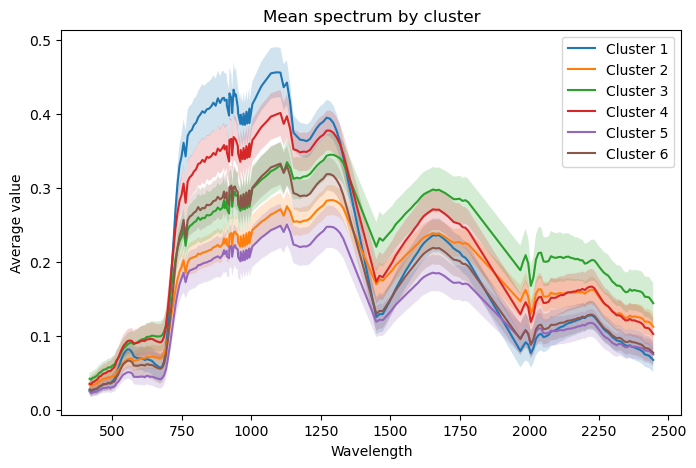

In [12]:
labels_veg = KMeans_mean_spectra(veg_pixels, veg_mask_1d, optimal_k_veg, l, wavelengths)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [13]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

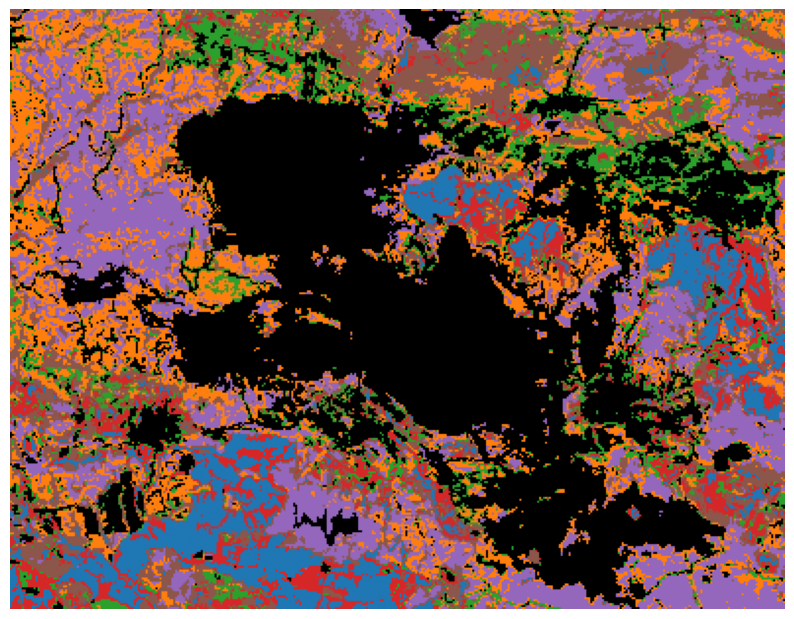

In [14]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [15]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = soil_pixels

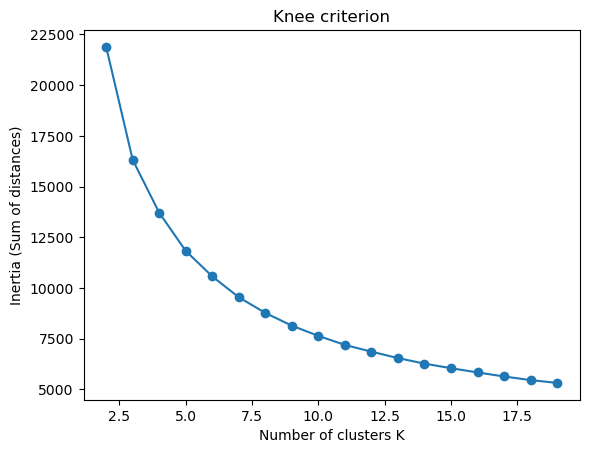

optimal value: k = 7


In [16]:
optimal_k_soil = compute_optimal_k(soil_pixels)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 15 instead. 

In [17]:
optimal_k_soil = 15

Silhouette (sampled) for k = 15 : 0.225


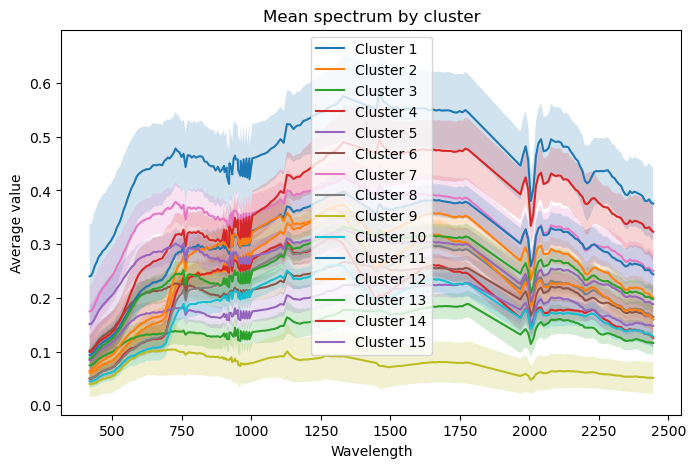

In [18]:
labels_soil = KMeans_mean_spectra(soil_pixels, soil_mask_1d, optimal_k_soil, l, wavelengths)

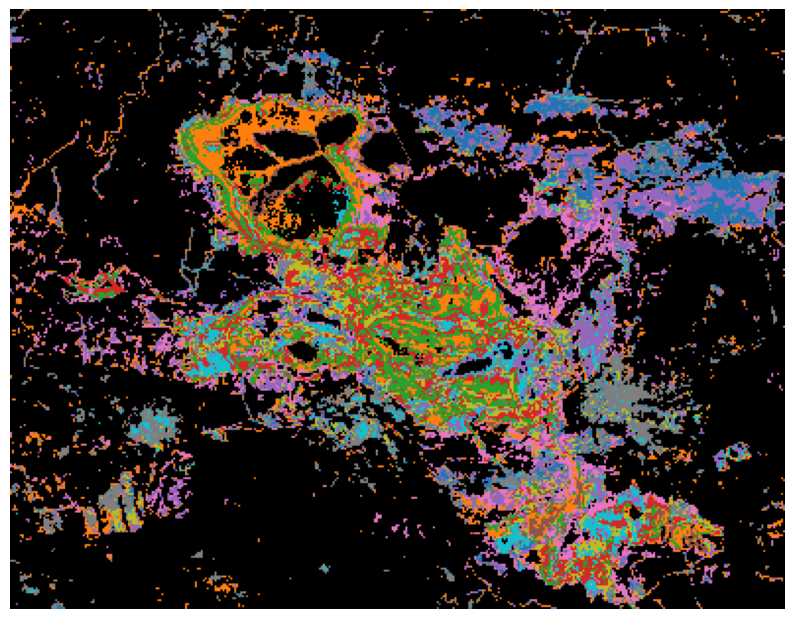

In [19]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [20]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = other_pixels

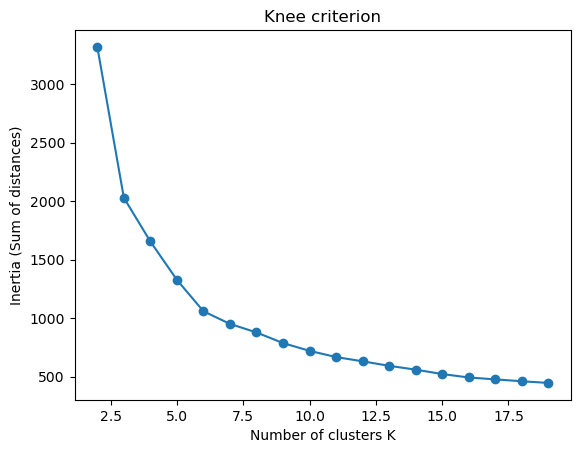

optimal value: k = 6


In [21]:
optimal_k_other = compute_optimal_k(other_pixels)

Silhouette (sampled) for k = 6 : 0.507


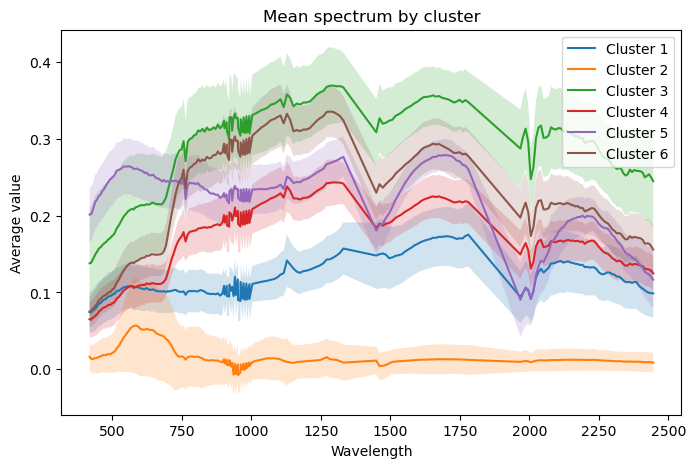

In [22]:
labels_other = KMeans_mean_spectra(other_pixels, other_mask_1d, optimal_k_other, l, wavelengths)

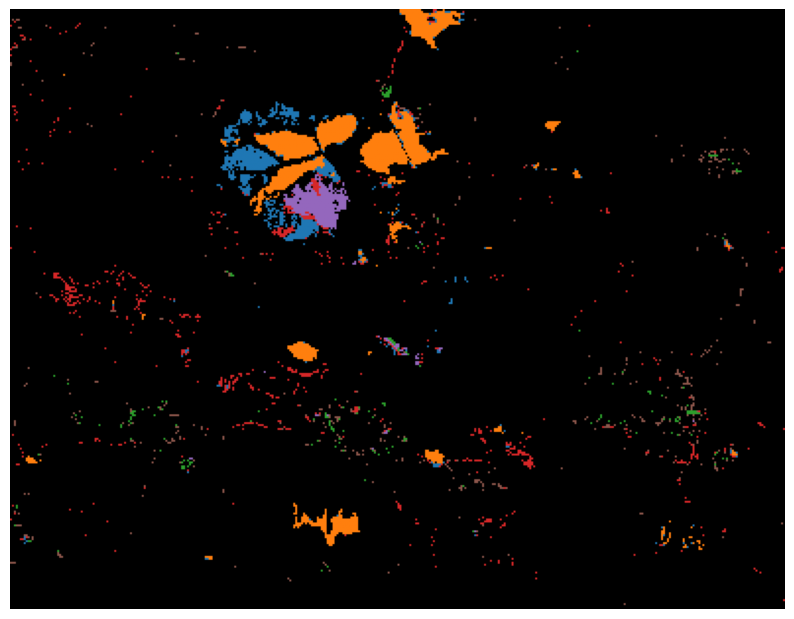

In [23]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [24]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(True),
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(256, in_dim),
            #nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [25]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [26]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples = 10000):

    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=1024, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=1024, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    model.eval()

    latent_vectors = []
    with torch.no_grad():
        for (x,) in loader_ordered:
            x = x.to(DEVICE)
            _, z = model(x)
            latent_vectors.append(z.cpu().numpy())
            
    latent_vectors = np.concatenate(latent_vectors, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=50, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if X_scaled.shape[0] > max_samples:
        idx = np.random.choice(X_scaled.shape[0], max_samples, replace=False)
        X_sample = X_scaled[idx]
        labels_sample = labels_1d[idx]
    else:
        X_sample = X_scaled
        labels_sample = labels_1d

    # Silhouette "Latente" (Espace du modèle) -> Séparabilité vue par le réseau
    sil_score = silhouette_score(X_sample, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels_1d

In [27]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation

In [28]:
LATENT_DIM = 16
N_EPOCHS = 25

labels_1d_veg = train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, veg_pixels, optimal_k_veg)

Epoch 1/25   Loss = 0.009749
Epoch 2/25   Loss = 0.001891
Epoch 3/25   Loss = 0.000884
Epoch 4/25   Loss = 0.000255
Epoch 5/25   Loss = 0.000188
Epoch 6/25   Loss = 0.000161
Epoch 7/25   Loss = 0.000148
Epoch 8/25   Loss = 0.000135
Epoch 9/25   Loss = 0.000136
Epoch 10/25   Loss = 0.000132
Epoch 11/25   Loss = 0.000129
Epoch 12/25   Loss = 0.000118
Epoch 13/25   Loss = 0.000120
Epoch 14/25   Loss = 0.000095
Epoch 15/25   Loss = 0.000102
Epoch 16/25   Loss = 0.000087
Epoch 17/25   Loss = 0.000088
Epoch 18/25   Loss = 0.000090
Epoch 19/25   Loss = 0.000063
Epoch 20/25   Loss = 0.000073
Epoch 21/25   Loss = 0.000065
Epoch 22/25   Loss = 0.000060
Epoch 23/25   Loss = 0.000072
Epoch 24/25   Loss = 0.000063
Epoch 25/25   Loss = 0.000070
Silhouette (échantillon) pour k = 6 : 0.273


In [33]:
def Mean_spectra(labels, mask_1D, optimal_k):
    
    bands_number = l
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = wavelengths
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()

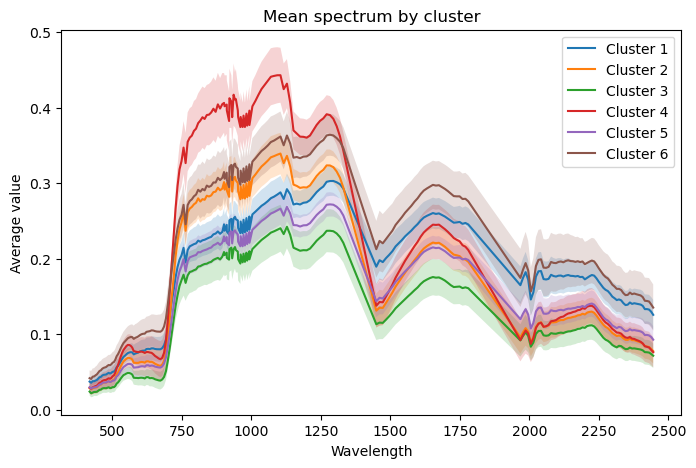

In [34]:
Mean_spectra(labels_1d_veg, veg_mask_1d, optimal_k_veg)

<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [ ]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, soil_pixels, optimal_k_soil)

Epoch 1/25   Loss = 0.020531
Epoch 2/25   Loss = 0.004142
Epoch 3/25   Loss = 0.002674
Epoch 4/25   Loss = 0.001432
Epoch 5/25   Loss = 0.000810
Epoch 6/25   Loss = 0.000631
Epoch 7/25   Loss = 0.000422
Epoch 8/25   Loss = 0.000320
Epoch 9/25   Loss = 0.000312
Epoch 10/25   Loss = 0.000274
Epoch 11/25   Loss = 0.000250
Epoch 12/25   Loss = 0.000274
Epoch 13/25   Loss = 0.000248
Epoch 14/25   Loss = 0.000301
Epoch 15/25   Loss = 0.000240
Epoch 16/25   Loss = 0.000239
Epoch 17/25   Loss = 0.000212
Epoch 18/25   Loss = 0.000234
Epoch 19/25   Loss = 0.000229
Epoch 20/25   Loss = 0.000216
Epoch 21/25   Loss = 0.000188
Epoch 22/25   Loss = 0.000202
Epoch 23/25   Loss = 0.000190
Epoch 24/25   Loss = 0.000177
Epoch 25/25   Loss = 0.000150
Silhouette (échantillon) pour k = 15 : 0.203


array([0, 8, 0, ..., 3, 3, 0], shape=(40789,), dtype=int32)

<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [ ]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, other_pixels, optimal_k_other)

Epoch 1/25   Loss = 0.071703
Epoch 2/25   Loss = 0.020837
Epoch 3/25   Loss = 0.011239
Epoch 4/25   Loss = 0.006752
Epoch 5/25   Loss = 0.004843
Epoch 6/25   Loss = 0.003262
Epoch 7/25   Loss = 0.002693
Epoch 8/25   Loss = 0.002225
Epoch 9/25   Loss = 0.001974
Epoch 10/25   Loss = 0.001790
Epoch 11/25   Loss = 0.001687
Epoch 12/25   Loss = 0.001619
Epoch 13/25   Loss = 0.001519
Epoch 14/25   Loss = 0.001449
Epoch 15/25   Loss = 0.001360
Epoch 16/25   Loss = 0.001272
Epoch 17/25   Loss = 0.001189
Epoch 18/25   Loss = 0.001083
Epoch 19/25   Loss = 0.000999
Epoch 20/25   Loss = 0.000883
Epoch 21/25   Loss = 0.000809
Epoch 22/25   Loss = 0.000743
Epoch 23/25   Loss = 0.000674
Epoch 24/25   Loss = 0.000630
Epoch 25/25   Loss = 0.000602
Silhouette (échantillon) pour k = 6 : 0.465


array([0, 3, 3, ..., 2, 4, 2], shape=(5407,), dtype=int32)

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [35]:
LATENT_DIM = 16
EPOCHS = 20
PATCH_SIZE = 3
STRIDE = 2
BATCH_SIZE = 256
VEG_THRESHOLD = 0.8

In [36]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=0),
            nn.GroupNorm(8, 64), 
            nn.ReLU(True),

            nn.Conv2d(64, 128, kernel_size=1, stride=1, padding=0),          # H/8
            nn.ReLU(True)
        )
        
        self.fc_enc = nn.Linear(128, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 128)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(128, 64, kernel_size=1, stride=1, padding=0),
            nn.GroupNorm(8,64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, in_channels, kernel_size=3, stride=1, padding=0),  # H*2
            #nn.Sigmoid() On veut pouvoir reconstruire des valeurs négatives : standard scaling
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(z_dec.size(0), 128, 1, 1)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent
    
    def encode(self, x):
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)
        z_latent = self.fc_enc(z_flat)
        return z_latent

In [37]:
def fill_invalid_pixels_with_mean(x_batch, mask_batch):
    """
    x_batch: (B, C, H, W)
    mask_batch: (B, H, W) avec 0 / 1
    """

    mask = mask_batch.unsqueeze(1)  # (B,1,H,W)

    # nombre de pixels valides par patch
    valid_count = mask.sum(dim=(2, 3), keepdim=True).clamp(min=1)

    # moyenne par canal et par patch
    mean_vals = (x_batch * mask).sum(dim=(2, 3), keepdim=True) / valid_count

    # remplacement
    x_filled = x_batch * mask + mean_vals * (1 - mask)

    return x_filled

In [38]:
def generate_valid_patches(img_tensor, mask_tensor, patch_size, stride, batch_size=BATCH_SIZE, min_valid_ratio=VEG_THRESHOLD):
    """
    Génère des batches d'apprentissage où chaque patch a au moins min_valid_ratio de pixels valides
    """
    _, H, W = img_tensor.shape
    # 1️⃣ Lister toutes les positions possibles
    positions = [(i,j) for i in range(0, H - patch_size + 1, stride) for j in range(0, W - patch_size + 1, stride)]
    random.shuffle(positions)
    patches = []

    for i, j in positions :
        patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
        mask_patch = mask_tensor[i:i+patch_size, j:j+patch_size]

        valid_ratio = mask_patch.sum() / (patch_size * patch_size)
        if valid_ratio < min_valid_ratio:
            continue  # rejet du patch

        # Remplacement des pixels invalides par la moyenne locale
        mask_patch_exp = mask_patch.unsqueeze(0)  # (1,H,W)
        valid_count = mask_patch_exp.sum(dim=(1,2), keepdim=True).clamp(min=1)
        mean_vals = (patch * mask_patch_exp).sum(dim=(1,2), keepdim=True) / valid_count
        patch_filled = patch * mask_patch_exp + mean_vals * (1 - mask_patch_exp)

        patches.append(patch_filled.unsqueeze(0))

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)

In [39]:
def generate_patches_centered(img_tensor, patch_size, sampled_positions, batch_size):
    """
    Génère des patches centrés sur les pixels de référence (i,j)
    """
    patches = []
    half = patch_size // 2
    C, H, W = img_tensor.shape

    for i,j in sampled_positions:
        i_start = i - half
        i_end   = i + half + 1
        j_start = j - half
        j_end   = j + half + 1

        # Clip pour rester dans l'image
        i_start_clip = max(0, i_start)
        i_end_clip   = min(H, i_end)
        j_start_clip = max(0, j_start)
        j_end_clip   = min(W, j_end)

        patch = img_tensor[:, i_start_clip:i_end_clip, j_start_clip:j_end_clip].unsqueeze(0)

        # Padding si nécessaire
        pad_top    = i_start_clip - i_start
        pad_bottom = i_end - i_end_clip
        pad_left   = j_start_clip - j_start
        pad_right  = j_end - j_end_clip

        patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom))
        patches.append(patch)

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)


def train_Conv2D_autoencoder(EPOCHS, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_BATCHES_PER_EPOCH):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    img_tensor = torch.Tensor(img_scaled_complete.T.reshape(l,m,n))
    mask_tensor = torch.Tensor(mask_2d)

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        accepted_batches = 0

        patch_gen = generate_valid_patches(
            img_tensor, mask_tensor,
            PATCH_SIZE, STRIDE, BATCH_SIZE, VEG_THRESHOLD
        )

        for batch in patch_gen:
            
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            out, _ = model(batch)
            loss = criterion(out, batch)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            accepted_batches += 1

            if accepted_batches >= MAX_BATCHES_PER_EPOCH:
                break

        print(f"Epoch {ep+1}/{EPOCHS} | Batches: {accepted_batches} | Loss: {loss_sum/max(1, accepted_batches):.6f}")

        torch.cuda.empty_cache()

    # --------------------------
    # PHASE 2 : EXTRACTION DES LATENTS
    # --------------------------
    model.eval()
    model.cpu()

    _, H, W = img_tensor.shape


    # 1️⃣ Lister tous les pixels valides pour le patch top-left
    valid_positions = [
        (i,j)
        for i in range(H)
        for j in range(W)
        if mask_tensor[i,j] == 1
    ]

    # 2️⃣ Construire patches centrés batch par batch
    all_latents = []
    INFERENCE_BATCH_SIZE = 1024
    for patch_batch in generate_patches_centered(img_tensor, PATCH_SIZE, valid_positions, batch_size=INFERENCE_BATCH_SIZE):
        with torch.no_grad():
            z = model.encode(patch_batch)  # (B, latent_dim)
        all_latents.append(z.cpu().numpy())
    latents = np.concatenate(all_latents, axis=0)

    return latents, valid_positions

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [40]:
def KM_Silhouette(img_2d, positions, latent_vectors, n_clusters, max_samples):
    kmeans = KMeans(n_clusters, n_init=100, random_state=0)
    scaler = StandardScaler()
    latent_norms = scaler.fit_transform(latent_vectors)
    labels = kmeans.fit_predict(latent_norms)
    X_phys_aligned = []

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if latent_vectors.shape[0] > max_samples:
        idx = np.random.choice(latent_vectors.shape[0], max_samples, replace=False)
        labels_sample = labels[idx]
    else:
        idx = np.arange(latent_vectors.shape[0])
        labels_sample = labels

    print("Extraction des pixels physiques alignés...")
    for id in idx:
        # C'est ICI que se joue l'alignement
        r, c = positions[id] 
        
        # On récupère la valeur du pixel à cette coordonnée précise
        pixel_val = img_2d[r, c, :] 
        X_phys_aligned.append(pixel_val)

    X_phys_aligned = np.array(X_phys_aligned)

    sil_score = silhouette_score(X_phys_aligned, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels

In [41]:
latent_vectors_veg, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_veg_complete, veg_mask_2d, MAX_BATCHES_PER_EPOCH=300
)


Utilization du device : cuda
Epoch 1/20 | Batches: 65 | Loss: 0.005125
Epoch 2/20 | Batches: 65 | Loss: 0.001298
Epoch 3/20 | Batches: 65 | Loss: 0.001067
Epoch 4/20 | Batches: 65 | Loss: 0.000932
Epoch 5/20 | Batches: 65 | Loss: 0.000762
Epoch 6/20 | Batches: 65 | Loss: 0.000683
Epoch 7/20 | Batches: 65 | Loss: 0.000671
Epoch 8/20 | Batches: 65 | Loss: 0.000627
Epoch 9/20 | Batches: 65 | Loss: 0.000651
Epoch 10/20 | Batches: 65 | Loss: 0.000594
Epoch 11/20 | Batches: 65 | Loss: 0.000544
Epoch 12/20 | Batches: 65 | Loss: 0.000495
Epoch 13/20 | Batches: 65 | Loss: 0.000479
Epoch 14/20 | Batches: 65 | Loss: 0.000448
Epoch 15/20 | Batches: 65 | Loss: 0.000423
Epoch 16/20 | Batches: 65 | Loss: 0.000378
Epoch 17/20 | Batches: 65 | Loss: 0.000377
Epoch 18/20 | Batches: 65 | Loss: 0.000368
Epoch 19/20 | Batches: 65 | Loss: 0.000337
Epoch 20/20 | Batches: 65 | Loss: 0.000370


In [42]:
labels_veg = KM_Silhouette(img_scaled_veg_complete.reshape(m,n,l), positions, latent_vectors_veg, optimal_k_veg, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 6 : 0.134


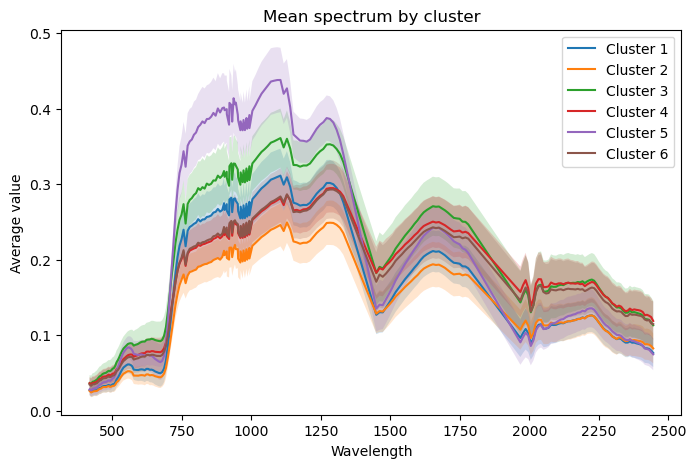

In [43]:
Mean_spectra(labels_veg, veg_mask_1d, optimal_k_veg)

In [ ]:
from collections import Counter
cluster_counts = Counter(labels_veg)
print(cluster_counts)

Counter({np.int32(0): 15904, np.int32(1): 15758, np.int32(4): 15496, np.int32(5): 13654, np.int32(2): 12498, np.int32(3): 4465})


<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [ ]:
latent_vectors_soil, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_soil_complete, soil_mask_2d, MAX_BATCHES_PER_EPOCH=300
)

Utilization du device : cuda
Epoch 1/20 | Batches: 27 | Loss: 0.012525
Epoch 2/20 | Batches: 27 | Loss: 0.004521
Epoch 3/20 | Batches: 27 | Loss: 0.004252
Epoch 4/20 | Batches: 27 | Loss: 0.003952
Epoch 5/20 | Batches: 27 | Loss: 0.003837
Epoch 6/20 | Batches: 27 | Loss: 0.003678
Epoch 7/20 | Batches: 27 | Loss: 0.004107
Epoch 8/20 | Batches: 27 | Loss: 0.003916
Epoch 9/20 | Batches: 27 | Loss: 0.003594
Epoch 10/20 | Batches: 27 | Loss: 0.003667
Epoch 11/20 | Batches: 27 | Loss: 0.003017
Epoch 12/20 | Batches: 27 | Loss: 0.003209
Epoch 13/20 | Batches: 27 | Loss: 0.002630
Epoch 14/20 | Batches: 27 | Loss: 0.002299
Epoch 15/20 | Batches: 27 | Loss: 0.001986
Epoch 16/20 | Batches: 27 | Loss: 0.002924
Epoch 17/20 | Batches: 27 | Loss: 0.001906
Epoch 18/20 | Batches: 27 | Loss: 0.001919
Epoch 19/20 | Batches: 27 | Loss: 0.001872
Epoch 20/20 | Batches: 27 | Loss: 0.001508


In [ ]:
labels_soil = KM_Silhouette(img_scaled_soil_complete.reshape(m,n,l), positions, latent_vectors_soil, optimal_k_soil, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 15 : 0.007


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [ ]:
latent_vectors_other, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_other_complete, other_mask_2d, MAX_BATCHES_PER_EPOCH=300
)

Utilization du device : cuda
Epoch 1/20 | Batches: 3 | Loss: 0.014390
Epoch 2/20 | Batches: 3 | Loss: 0.008353
Epoch 3/20 | Batches: 3 | Loss: 0.005828
Epoch 4/20 | Batches: 3 | Loss: 0.004007
Epoch 5/20 | Batches: 3 | Loss: 0.002367
Epoch 6/20 | Batches: 3 | Loss: 0.001758
Epoch 7/20 | Batches: 3 | Loss: 0.001807
Epoch 8/20 | Batches: 3 | Loss: 0.001498
Epoch 9/20 | Batches: 3 | Loss: 0.001259
Epoch 10/20 | Batches: 3 | Loss: 0.001367
Epoch 11/20 | Batches: 3 | Loss: 0.001331
Epoch 12/20 | Batches: 3 | Loss: 0.001198
Epoch 13/20 | Batches: 3 | Loss: 0.001224
Epoch 14/20 | Batches: 3 | Loss: 0.001110
Epoch 15/20 | Batches: 3 | Loss: 0.000907
Epoch 16/20 | Batches: 3 | Loss: 0.000794
Epoch 17/20 | Batches: 3 | Loss: 0.000799
Epoch 18/20 | Batches: 3 | Loss: 0.000655
Epoch 19/20 | Batches: 3 | Loss: 0.000701
Epoch 20/20 | Batches: 3 | Loss: 0.000684


In [ ]:
labels_other = KM_Silhouette(img_scaled_other_complete.reshape(m,n,l), positions, latent_vectors_other, optimal_k_other, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 6 : 0.170


<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.4 Nombre de clusters pour la végétation avec CDH

In [ ]:
N = 20000
idx = np.random.choice(len(veg_pixels), N, replace=False)
X_sample = veg_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

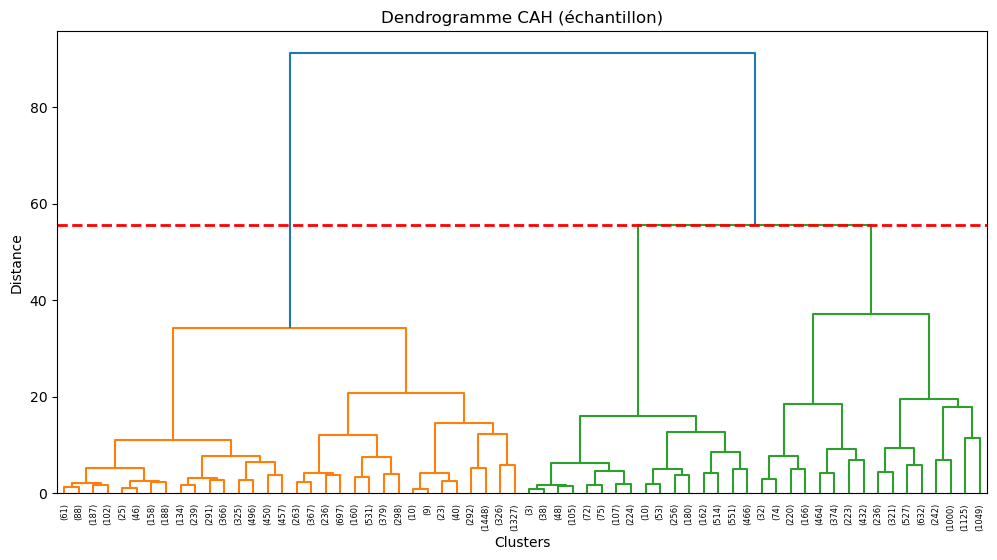

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

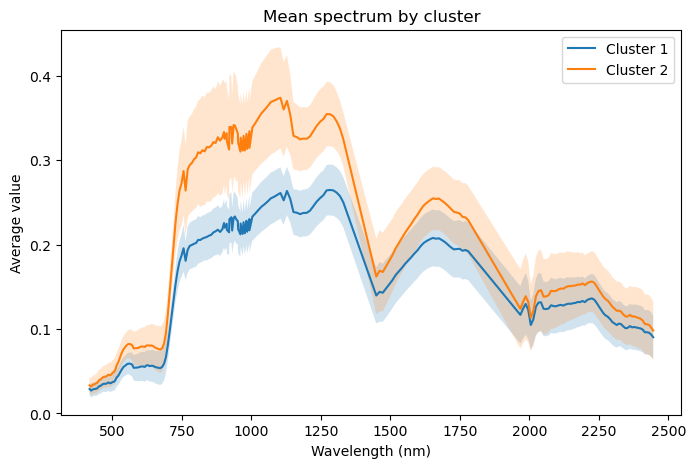

In [ ]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Clusters can be associated to different kinds of vegetation which is more or less sane depending on the mean spectrum : a lower reflectance means that the vegetation is less dense/sane while a higher reflectance indicates luxurious vegetation.

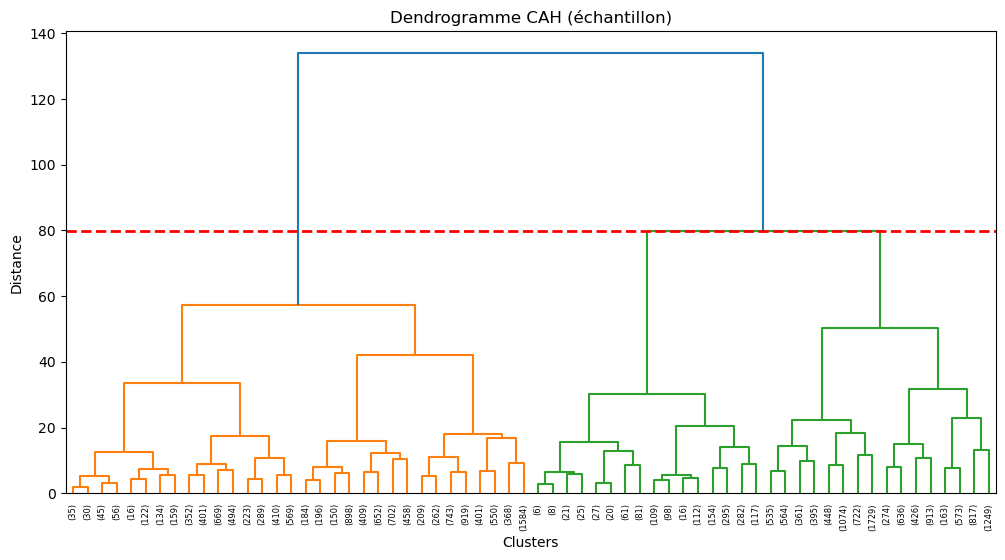

In [ ]:
N = 25000
idx = np.random.choice(len(soil_pixels), N, replace=False)
X_sample = soil_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


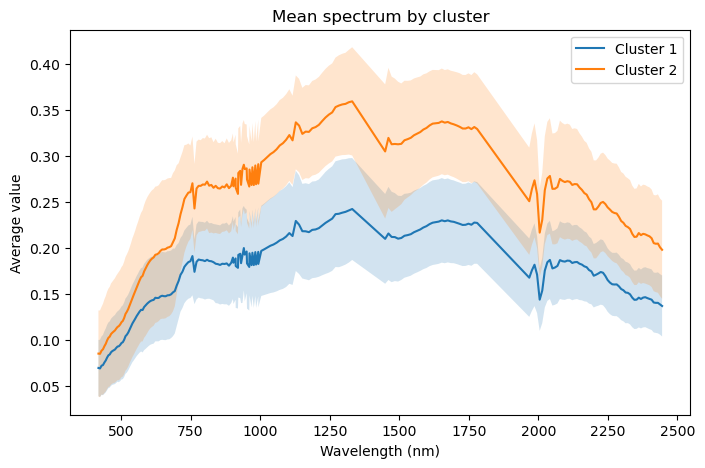

In [ ]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the soil. The mean spectrum shows that both clusters have similar shapes, but that cluster one has lower reflectance, which could be due to the presence of water. Thus, we can suggest that cluster one corresponds to wet soils (agricultural soils, loamy soils...) and cluster two to drier soil areas.

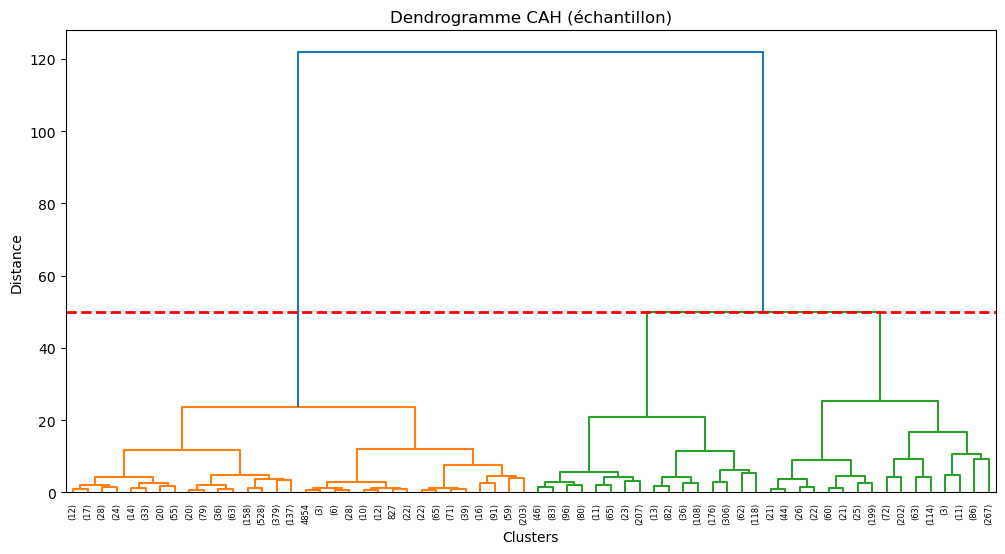

In [ ]:
N = 5000
idx = np.random.choice(len(other_pixels), N, replace=False)
X_sample = other_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

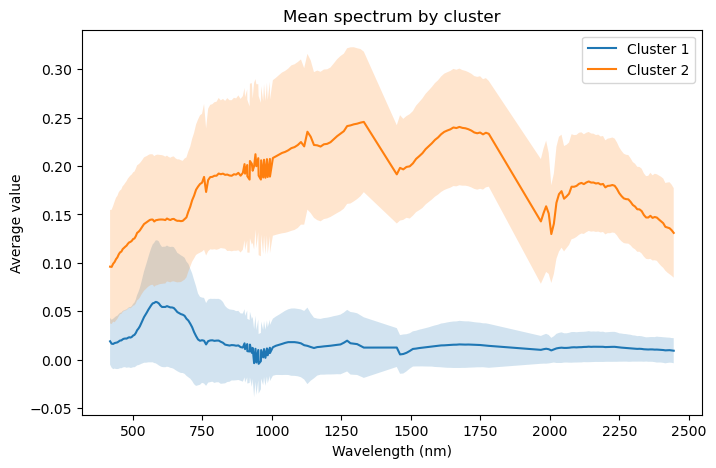

In [ ]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the remaining pixels. Cluster one, with very low reflectance, has a shape that is characteristic of water areas (shallow water). Cluster two has a shape that recalls the spectrum of concrete or similar materials, which could be associated to more urban areas.

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    5. Deep Clustering

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
For deep clustering, we will select "valid" patches from the original image and train an Autoencoder on those patches. Then we will train a clustering layer on the outputs of Autoencoder that will force separation between the clusters.

In [44]:
# ==========================================
# 1. PARAMÈTRES ET CONFIGURATION
# ==========================================
PATCH_SIZE = 3 
STRIDE = 2 # Pour l'apprentissage, pas le test !
BATCH_SIZE = 512
LATENT_DIM = 64
N_CLUSTERS = 6
MIN_VALID_RATIO = 0.8
LAMBDA = 0.1
N_EPOCHS_AE = 25
N_EPOCHS_CLUSTERING = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

Utilisation de l'appareil : cuda


In [45]:
class ConvAutoencoder_forDC(nn.Module):
    def __init__(self, in_channels, latent_dim):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder_forDC, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=1, padding=0),  # H/2
            nn.GroupNorm(8, 64),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 1, stride=1, padding=0),           # H/4
            #nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(True),
            #ResidualBlock(64),  # Residual pour enrichir la représentation

        )
        
         # PAS de pooling global
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(128, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 128)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(128, 64, 1, stride=1, padding=0),
            nn.GroupNorm(8, 64),
            nn.ReLU(True),
            #ResidualBlock(128),

            nn.ConvTranspose2d(64, in_channels, 3, stride=1, padding=0),  # H*2
            #nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        z = self.fc_enc(self.flatten(h))
        return z

    def forward(self, x):
        # Encoder
        z_latent = self.encode(x)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(-1, 128, 1, 1)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent

In [46]:
class DeepClusteringDataset(Dataset):
    def __init__(self, img_tensor, mask_tensor, patch_size, stride, min_valid_ratio):
        self.img_tensor = img_tensor
        self.mask_tensor = mask_tensor
        self.patch_size = patch_size
        
        # On utilise l'optimisation par convolution pour lister les positions valides dès le départ
        self.positions = self._get_valid_indices(mask_tensor, patch_size, stride, min_valid_ratio)
        
    def _get_valid_indices(self, mask_tensor, patch_size, stride, min_valid_ratio):
        mask_4d = mask_tensor.unsqueeze(0).unsqueeze(0).float()
        kernel = torch.ones((1, 1, patch_size, patch_size))
        valid_sums = torch.nn.functional.conv2d(mask_4d, kernel, stride=stride)
        valid_ratios = valid_sums / (patch_size * patch_size)
        indices = (valid_ratios >= min_valid_ratio).nonzero(as_tuple=False)
        return [(idx[2].item() * stride, idx[3].item() * stride) for idx in indices]

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        i, j = self.positions[idx]
        patch = self.img_tensor[:, i:i+self.patch_size, j:j+self.patch_size].clone()
        mask_patch = self.mask_tensor[i:i+self.patch_size, j:j+self.patch_size].clone()

        # On retourne le patch et le masque
        return patch, mask_patch

<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
5.1. Vegetation

In [47]:
# 1. Conversion explicite en Tenseurs PyTorch
# .float() est nécessaire pour la convolution plus bas
img_veg_torch = torch.from_numpy(img_scaled_veg_complete.reshape(n,m,l).T).float()
mask_veg_torch = torch.from_numpy(veg_mask_2d).float()

#print(veg_mask_2d.shape)

# 1. Instanciation du Dataset
veggie_ds = DeepClusteringDataset(
    img_tensor=img_veg_torch, 
    mask_tensor=mask_veg_torch, 
    patch_size=PATCH_SIZE, 
    stride=STRIDE, 
    min_valid_ratio=MIN_VALID_RATIO
)

# 2. Création du DataLoader compatible avec le script d'entraînement
dataloader_veg = DataLoader(
    veggie_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Mélange les patchs à chaque époque
    num_workers=0,     # Accélère le chargement via CPU multi-threading
    pin_memory=True,    # Accélère le transfert vers le GPU
    persistent_workers = False
)

In [48]:
class DeepClusteringWrapper(nn.Module):
    def __init__(self, autoencoder, n_clusters=N_CLUSTERS, latent_dim=LATENT_DIM, alpha=1.0):
        super(DeepClusteringWrapper, self).__init__()
        self.ae = autoencoder
        self.alpha = alpha
        # Centres des clusters (seront initialisés par K-Means)
        self.centroids = nn.Parameter(torch.zeros(n_clusters, latent_dim))

    def forward(self, x):
        # On utilise ta méthode .encode()
        z = self.ae.encode(x)
        z = F.normalize(z, dim=1)   # ← AJOUT MINIMAL
        centroids = F.normalize(self.centroids, dim=1)

        # Calcul de la distribution Q (Soft Assignment) basé sur t-Student
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - centroids)**2, 2) / self.alpha)
        q = q**((self.alpha + 1.0) / 2.0)
        q = (q.t() / (torch.sum(q, 1) + 1e-8)).t()
        return z, q

    @staticmethod
    def target_distribution(q):
        """Calcule la distribution cible P pour 'durcir' les clusters"""
        weight = q**2 / (q.sum(0) + 1e-8)
        return (weight.t() / (weight.sum(1)+1e-8)).t()

In [49]:
def train_model(autoencoder, dataloader, NEPOCHS_ae, NEPOCHS_clustering, n_clusters, latent_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    autoencoder.to(device)
    
    # --- ÉTAPE 1 : PRÉ-ENTRAÎNEMENT (Apprendre les textures) ---
    # On entraîne l'AE à reconstruire les patchs de végétation
    print("Phase 1 : Pré-entraînement de l'Autoencodeur...")
    optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

    # Utilisation du scaler pour le Mixed Precision (vitesse ++ sur RTX 5060)
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(NEPOCHS_ae): # Ajustable
        autoencoder.train()
        total_loss = 0
        for data, masks in dataloader:
            data = data.to(device, non_blocking = True)
            masks = masks.to(device, non_blocking=True).float() 

            masks = masks.unsqueeze(1)

            masks_expanded = masks.expand_as(data)

            with torch.no_grad():
                # Somme des pixels valides par canal / nombre de pixels valides
                sum_val = (data * masks_expanded).sum(dim=(2, 3), keepdim=True)
                count_val = masks_expanded.sum(dim=(2, 3), keepdim=True) + 1e-8
                mean_patch = sum_val / count_val
                
                # On remplace les 0 par la moyenne + un micro-bruit (0.01) pour la texture
                #noise = torch.randn_like(data) * 0.01
                data_filled = torch.where(masks_expanded == 1, data, mean_patch)

            """
                    # AUGMENTATION : Flip Aléatoire (Horizontal & Vertical)
            if np.random.rand() > 0.5:
                k = np.random.randint(1, 4)
                data = torch.rot90(data, k, dims=[2, 3])
                masks = torch.rot90(masks, k, dims=[2, 3])
            """

            with torch.amp.autocast('cuda'): # Accélère le calcul sur Blackwell
                recon, _ = autoencoder(data_filled)
                # --- CALCUL DE LA MSE MASQUÉE ---
            # On multiplie l'erreur par le masque pour annuler les pixels invalides
                squared_diff = (recon - data) ** 2

                masked_error = squared_diff * masks_expanded

                # Moyenne uniquement sur les pixels valides
                loss = masked_error.sum() / (masks_expanded.sum() + 1e-8)
            
            optimizer_ae.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer_ae)
            scaler.update()

            total_loss += loss.item()
        print(f"Epoch {epoch+1} - MSE Loss: {total_loss/len(dataloader):.6f}")

    # --- ÉTAPE 2 : INITIALISATION DES CENTRES ---
    print("\nPhase 2 : Initialisation des clusters avec K-Means...")
    autoencoder.eval()
    all_z = []
    with torch.no_grad():
        for data, masks in dataloader:
            # On utilise aussi l'imputation pour l'encodage final avant K-means
            data = data.to(device)
            masks = masks.to(device).float()
            masks = masks.unsqueeze(1)
            masks_exp = masks.to(device).expand_as(data.to(device))
            m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
            d_filled = torch.where(masks_exp == 1, data, m_patch)
            z = autoencoder.encode(d_filled)
            all_z.append(z.cpu().numpy())
    
    all_z = np.concatenate(all_z, axis = 0)
    kmeans = KMeans(n_clusters=n_clusters, n_init=100, random_state=0)
    kmeans.fit(all_z)

    counts = np.bincount(kmeans.labels_)
    print(f"Répartition initiale K-Means : {counts}")
    
    # Création du modèle DEC complet
    model = DeepClusteringWrapper(autoencoder, n_clusters, latent_dim).to(device)
    model.centroids.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

    # --- ÉTAPE 3 : RAFFINEMENT (Deep Clustering) ---
    # Avant la Phase 3
    # 1. On crée un dataloader SANS shuffle pour garantir l'ordre des indices
    dataloader_fixed = DataLoader(
        dataloader.dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False,  # <--- CRUCIAL : l'ordre ne change plus
        num_workers=dataloader.num_workers,
        pin_memory=True
    )
    print("\nPhase 3 : Raffinement par divergence KL...")
    # On utilise souvent un LR plus faible et SGD pour la stabilité du clustering
    # --- PHASE 3 : Optimisation Asymétrique ---
    optimizer_dec = torch.optim.Adam([
        # On bride l'autoencodeur pour protéger les textures
        {'params': model.ae.parameters(), 'lr': 1e-7}, 
        
        # On laisse les centroïdes s'ajuster aux données
        {'params': model.centroids, 'lr': 1e-5}
    ])
    criterion_kl = nn.KLDivLoss(reduction='batchmean')

    for epoch in range(NEPOCHS_clustering):
        model.eval()

        all_q = []
        with torch.no_grad():
            for data, masks in dataloader_fixed:
                masks = masks.unsqueeze(1)
                masks_exp = masks.to(device).expand_as(data.to(device))
                m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
                d_filled = torch.where(masks_exp == 1, data.to(device), m_patch)
                _, q = model(d_filled)
                all_q.append(q.cpu())
        
        all_q = torch.cat(all_q, dim=0)
        all_p = model.target_distribution(all_q).detach()

        model.train()
        total_kl, total_mse = 0, 0
        cursor = 0 # Pour suivre la position dans all_p
        
        for data, masks in dataloader_fixed:
            data = data.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).float()
            masks = masks.unsqueeze(1)
            
            # Extraction de la cible correspondante au batch
            current_batch_size = data.size(0)
            p_batch = all_p[cursor:cursor+current_batch_size].to(device)
            cursor += current_batch_size

            # Note : Pas d'autocast ici pour la précision de la divergence KL
            z, q = model(data)
            
            # 3. Minimiser KL(P || Q)
            loss_kl = criterion_kl((q+1e-10).log(), p_batch)

                        # On force le décodeur à toujours savoir reconstruire le patch
            recon, _ = model.ae(data)
            squared_diff = (recon - data)**2
            masks_expanded = masks.expand_as(data)
            loss_mse = (squared_diff * masks_expanded).sum() / (masks_expanded.sum() + 1e-8)

            # Perte combinée
            total_loss = loss_kl + LAMBDA * loss_mse 
            
            optimizer_dec.zero_grad()
            total_loss.backward()
            optimizer_dec.step()
            total_kl += loss_kl.item()
            total_mse += loss_mse.item()
            
        print(f"Epoch {epoch+1} - KL: {total_kl/len(dataloader):.6f} | MSE: {total_mse/len(dataloader):.6f}")
    
    return model

In [50]:
CHANNELS = l # Nombre de bandes (ex: 3 pour RGB, 4 pour RGB-NIR)
ae = ConvAutoencoder_forDC(in_channels=CHANNELS, latent_dim=LATENT_DIM)

In [51]:
model_final = train_model(
    ae, 
    dataloader_veg, 
    N_EPOCHS_AE,           # Phase de reconstruction
    N_EPOCHS_CLUSTERING,   # Phase de raffinement des clusters
    N_CLUSTERS,
    LATENT_DIM
)

# Sauvegarde du modèle pour ne pas perdre l'apprentissage
torch.save(model_final.state_dict(), "dec_model_vegetation.pth")
print("Modèle entraîné et sauvegardé !")

Phase 1 : Pré-entraînement de l'Autoencodeur...
Epoch 1 - MSE Loss: 0.009602
Epoch 2 - MSE Loss: 0.004474
Epoch 3 - MSE Loss: 0.003639
Epoch 4 - MSE Loss: 0.002559
Epoch 5 - MSE Loss: 0.001895
Epoch 6 - MSE Loss: 0.001641
Epoch 7 - MSE Loss: 0.001446
Epoch 8 - MSE Loss: 0.001404
Epoch 9 - MSE Loss: 0.001153
Epoch 10 - MSE Loss: 0.001103
Epoch 11 - MSE Loss: 0.001043
Epoch 12 - MSE Loss: 0.000976
Epoch 13 - MSE Loss: 0.000954
Epoch 14 - MSE Loss: 0.000911
Epoch 15 - MSE Loss: 0.000892
Epoch 16 - MSE Loss: 0.000874
Epoch 17 - MSE Loss: 0.000830
Epoch 18 - MSE Loss: 0.000781
Epoch 19 - MSE Loss: 0.000849
Epoch 20 - MSE Loss: 0.000768
Epoch 21 - MSE Loss: 0.000731
Epoch 22 - MSE Loss: 0.000777
Epoch 23 - MSE Loss: 0.001194
Epoch 24 - MSE Loss: 0.000788
Epoch 25 - MSE Loss: 0.000746

Phase 2 : Initialisation des clusters avec K-Means...
Répartition initiale K-Means : [ 592 4717 3041  491  545 7125]

Phase 3 : Raffinement par divergence KL...
Epoch 1 - KL: 0.007592 | MSE: 0.000691
Epoch 2 - 

Extraction des caractéristiques latentes...
Calcul du t-SNE (cela peut prendre une minute)...


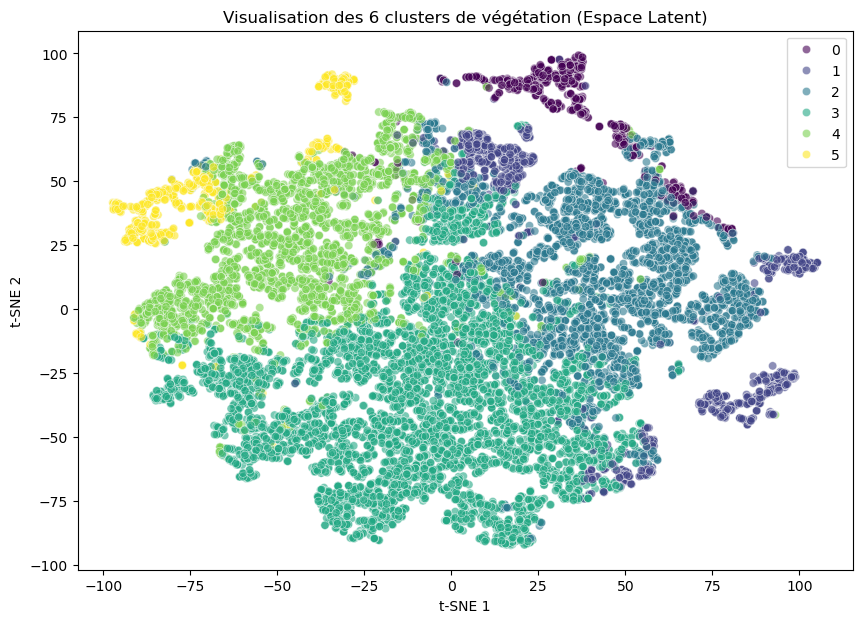

In [ ]:
def plot_clusters(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    latent_features = []
    labels = []
    
    print("Extraction des caractéristiques latentes...")
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            z, q = model(data)
            
            # On prend le cluster avec la probabilité la plus haute
            cluster_preds = torch.argmax(q, dim=1)
            
            latent_features.append(z.cpu().numpy())
            labels.append(cluster_preds.cpu().numpy())
            
    latent_features = np.concatenate(latent_features, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    # Réduction de dimension t-SNE (64D -> 2D)
    print("Calcul du t-SNE (cela peut prendre une minute)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(latent_features)
    
    # Affichage
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=z_2d[:,0], y=z_2d[:,1], hue=labels, palette='viridis', legend='full', alpha=0.6)
    plt.title(f"Visualisation des {len(np.unique(labels))} clusters de végétation (Espace Latent)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

# Utilisation :
plot_clusters(model_final, dataloader_veg)

In [59]:
def generate_map_batch_central(model, img_tensor, mask_tensor, patch_size=PATCH_SIZE, batch_size=BATCH_SIZE):
    """
    Génère la carte de clusters en assignant à chaque pixel central la classe de son patch.
    Utilise le GPU en mode batch pour la rapidité.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # S'assurer que l'entrée est un tenseur PyTorch pour le slicing rapide
    if isinstance(img_tensor, np.ndarray):
        img_tensor = torch.from_numpy(img_tensor).float()
    if isinstance(mask_tensor, np.ndarray):
        mask_tensor = torch.from_numpy(mask_tensor).float()
    
    C, H, W = img_tensor.shape
    offset = patch_size // 2
    
    # --- 2. PADDING (LA SOLUTION AU CRASH) ---
    # On ajoute 'offset' pixels de chaque côté. 
    # mode='reflect' copie les pixels du bord pour ne pas créer de fausses frontières noires.
    print(f"Padding de l'image (ajout de {offset} pixels sur les bords)...")
    img_padded = F.pad(img_tensor, (offset, offset, offset, offset), mode='reflect')
    
    # Carte de sortie
    final_map = np.full((H, W), -1, dtype=np.int8)
    
    # On liste toutes les coordonnées (i, j) des coins supérieurs gauches valides
    # Un coin est valide si son pixel central correspondant n'est pas masqué
    print("Calcul des coordonnées valides...")
    valid_coords = []
    
    # On utilise torch.nonzero pour aller beaucoup plus vite que la boucle for python
    # Cela retourne tous les indices [i, j] où le masque vaut 1
    indices = torch.nonzero(mask_tensor == 1, as_tuple=False).tolist()
    valid_coords = indices # Liste de [i, j]
    
    print(f"Nombre de patchs à traiter : {len(valid_coords)}")
    
    # Traitement par batchs
    with torch.no_grad():
        for b in tqdm(range(0, len(valid_coords), batch_size)):
            batch_indices = valid_coords[b : b + batch_size]
            
            # Préparation du batch de patchs
            patch_list = []
            for i, j in batch_indices:
                patch = img_padded[:, i:i+patch_size, j:j+patch_size]
                patch_list.append(patch)
            
            # Transfert groupé sur GPU
            batch_tensor = torch.stack(patch_list).to(device)
            
            # Inférence DEC
            # On passe par l'imputation rapide si nécessaire ou directement
            # Si vous avez des pixels invalides INTERNES au patch, appliquez le remplissage ici
            _, q = model(batch_tensor)
            clusters = torch.argmax(q, dim=1).cpu().numpy()
            
            # Assignation des résultats aux pixels centraux
            for idx, (i, j) in enumerate(batch_indices):
                final_map[i, j] = clusters[idx]
                
    return final_map

(120170, 219)
Padding de l'image (ajout de 1 pixels sur les bords)...
Calcul des coordonnées valides...
Nombre de patchs à traiter : 79117


100%|██████████| 155/155 [00:03<00:00, 40.97it/s]


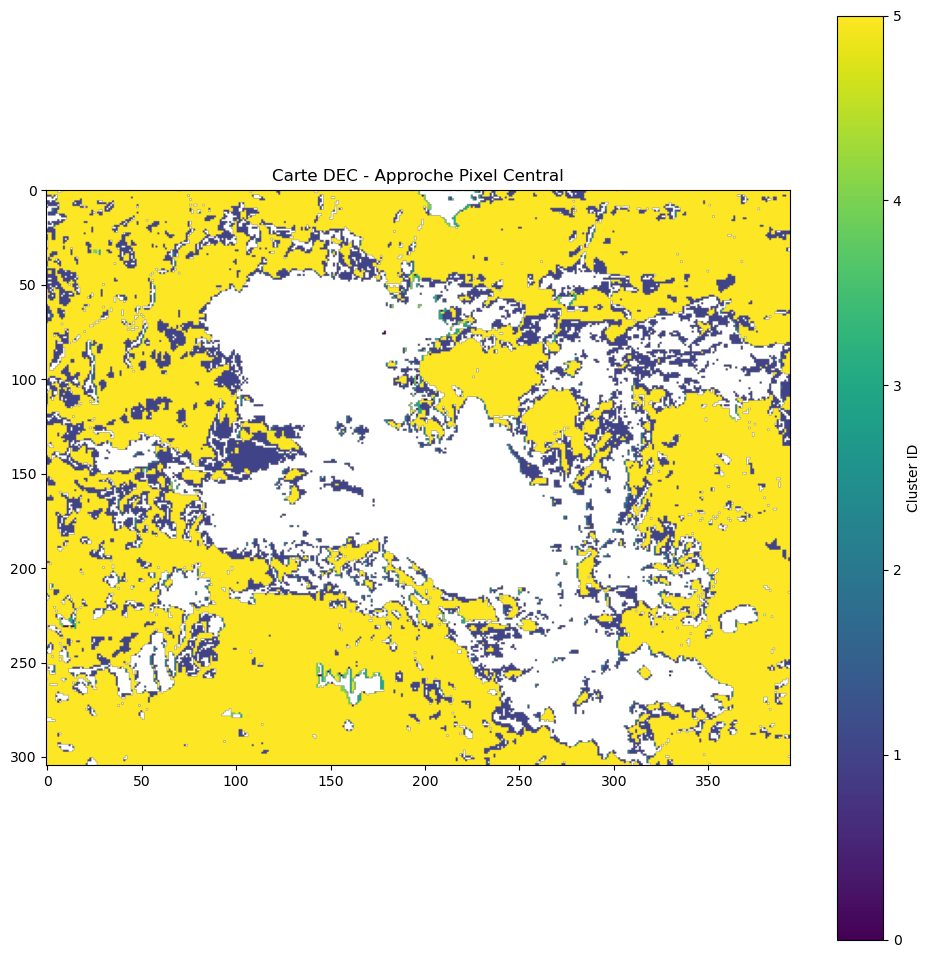

In [60]:
print(img_scaled_veg_complete.shape)

final_map = generate_map_batch_central(model_final, img_scaled_veg_complete.T.reshape(-1,m,n), veg_mask_2d)

# On masque les valeurs -1 pour l'affichage
display_map = np.ma.masked_where(final_map == -1, final_map)

plt.figure(figsize=(12, 12))
plt.imshow(display_map, cmap='viridis') # Ou 'terrain' pour la végétation
plt.colorbar(label='Cluster ID')
plt.title("Carte DEC - Approche Pixel Central")
plt.show()

In [61]:
# Distribution sur la carte finale (on exclut le fond -1)
unique_map, counts_map = np.unique(final_map[final_map != -1], return_counts=True)
print("Distribution Carte :", dict(zip(unique_map, counts_map)))

Distribution Carte : {np.int8(0): np.int64(47), np.int8(1): np.int64(14437), np.int8(2): np.int64(1168), np.int8(3): np.int64(222), np.int8(4): np.int64(167), np.int8(5): np.int64(63076)}


In [53]:
def Silhouette(img_2d, final_map, n_clusters, max_samples):

    X_phys_aligned = []

    positions = np.argwhere(final_map != -1)
    labels = final_map[final_map != -1]

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if positions.shape[0] > max_samples:
        idx = np.random.choice(positions.shape[0], max_samples, replace=False)
        labels_sample = labels[idx]
    else:
        idx = np.arange(positions.shape[0])
        labels_sample = labels

    print("Extraction des pixels physiques alignés...")
    for id in idx:
        # C'est ICI que se joue l'alignement
        r, c = positions[id] 
        
        # On récupère la valeur du pixel à cette coordonnée précise
        pixel_val = img_2d[r, c, :] 
        X_phys_aligned.append(pixel_val)

    X_phys_aligned = np.array(X_phys_aligned)

    sil_score = silhouette_score(X_phys_aligned, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels

In [62]:
labels_veg = Silhouette(img_scaled_veg_complete.reshape(m,n,l), final_map, optimal_k_veg, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 6 : 0.048


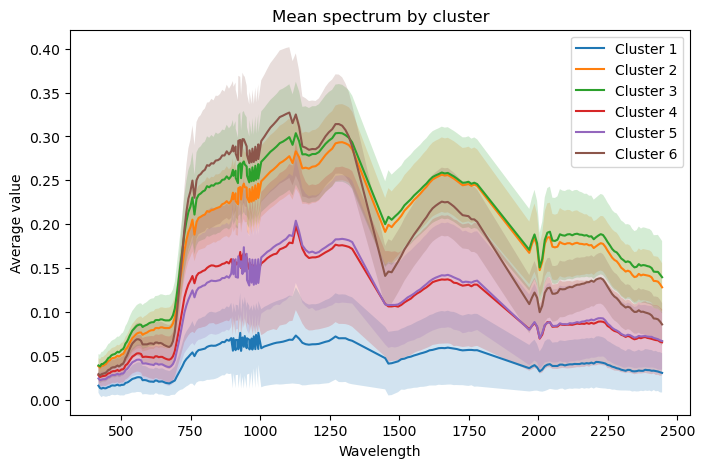

In [63]:
Mean_spectra(labels_veg, veg_mask_1d, optimal_k_veg)

<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
5.2. Soil

In [ ]:
# 1. Conversion explicite en Tenseurs PyTorch
# .float() est nécessaire pour la convolution plus bas
img_soil_torch = torch.from_numpy(img_scaled_soil_complete.reshape(n,m,l).T).float()
mask_soil_torch = torch.from_numpy(soil_mask_2d).float()

#print(veg_mask_2d.shape)

# 1. Instanciation du Dataset
soil_ds = DeepClusteringDataset(
    img_tensor=img_soil_torch, 
    mask_tensor=mask_soil_torch, 
    patch_size=PATCH_SIZE, 
    stride=STRIDE, 
    min_valid_ratio=MIN_VALID_RATIO
)

# 2. Création du DataLoader compatible avec le script d'entraînement
dataloader_soil = DataLoader(
    soil_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Mélange les patchs à chaque époque
    num_workers=0,     # Accélère le chargement via CPU multi-threading
    pin_memory=True,    # Accélère le transfert vers le GPU
    persistent_workers = False
)

In [ ]:
CHANNELS = l # Nombre de bandes (ex: 3 pour RGB, 4 pour RGB-NIR)
ae_soil = ConvAutoencoder_forDC(in_channels=CHANNELS, latent_dim=LATENT_DIM)

In [ ]:
model_final_soil = train_model(
    ae_soil, 
    dataloader_soil, 
    N_EPOCHS_AE,           # Phase de reconstruction
    N_EPOCHS_CLUSTERING,   # Phase de raffinement des clusters
    optimal_k_soil,
    LATENT_DIM
)

# Sauvegarde du modèle pour ne pas perdre l'apprentissage
torch.save(model_final_soil.state_dict(), "dec_model_soil.pth")
print("Modèle entraîné et sauvegardé !")

Phase 1 : Pré-entraînement de l'Autoencodeur...
Epoch 1 - MSE Loss: 0.017224
Epoch 2 - MSE Loss: 0.005567
Epoch 3 - MSE Loss: 0.005002
Epoch 4 - MSE Loss: 0.004909
Epoch 5 - MSE Loss: 0.004868
Epoch 6 - MSE Loss: 0.004859
Epoch 7 - MSE Loss: 0.004767
Epoch 8 - MSE Loss: 0.004362
Epoch 9 - MSE Loss: 0.003885
Epoch 10 - MSE Loss: 0.003310
Epoch 11 - MSE Loss: 0.003025
Epoch 12 - MSE Loss: 0.002779
Epoch 13 - MSE Loss: 0.002598
Epoch 14 - MSE Loss: 0.002495
Epoch 15 - MSE Loss: 0.002351
Epoch 16 - MSE Loss: 0.002016
Epoch 17 - MSE Loss: 0.001755
Epoch 18 - MSE Loss: 0.001601
Epoch 19 - MSE Loss: 0.001531
Epoch 20 - MSE Loss: 0.001452
Epoch 21 - MSE Loss: 0.001416
Epoch 22 - MSE Loss: 0.001382
Epoch 23 - MSE Loss: 0.001821
Epoch 24 - MSE Loss: 0.001469
Epoch 25 - MSE Loss: 0.001362

Phase 2 : Initialisation des clusters avec K-Means...
Répartition initiale K-Means : [126 588 347 554 617 448 670 128 524 542 123 484 570 554 580]

Phase 3 : Raffinement par divergence KL...
Epoch 1 - KL: 0.008

Extraction des caractéristiques latentes...
Calcul du t-SNE (cela peut prendre une minute)...


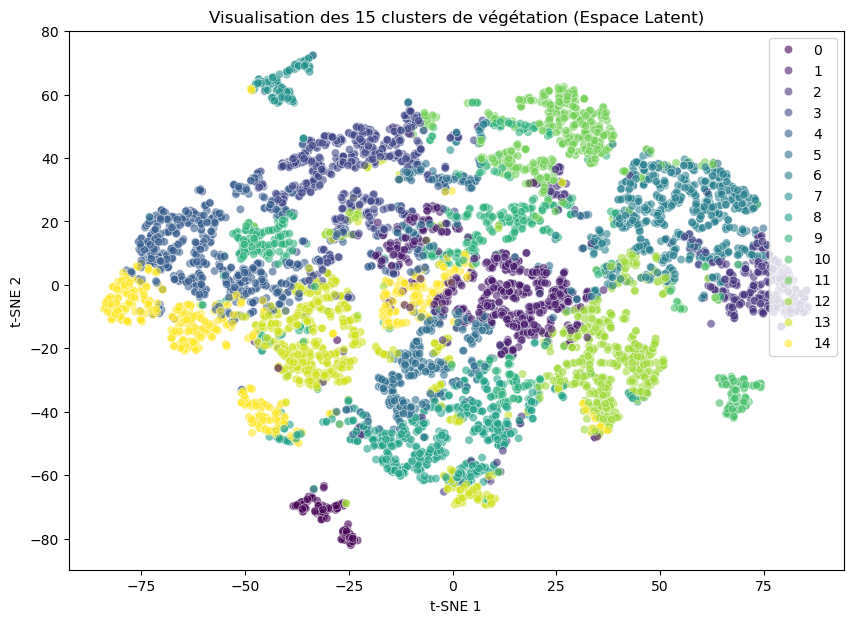

In [ ]:
# Utilisation :
plot_clusters(model_final_soil, dataloader_soil)

Calcul des coordonnées valides...
Nombre de patchs à traiter : 40686


100%|██████████| 80/80 [00:02<00:00, 32.48it/s]


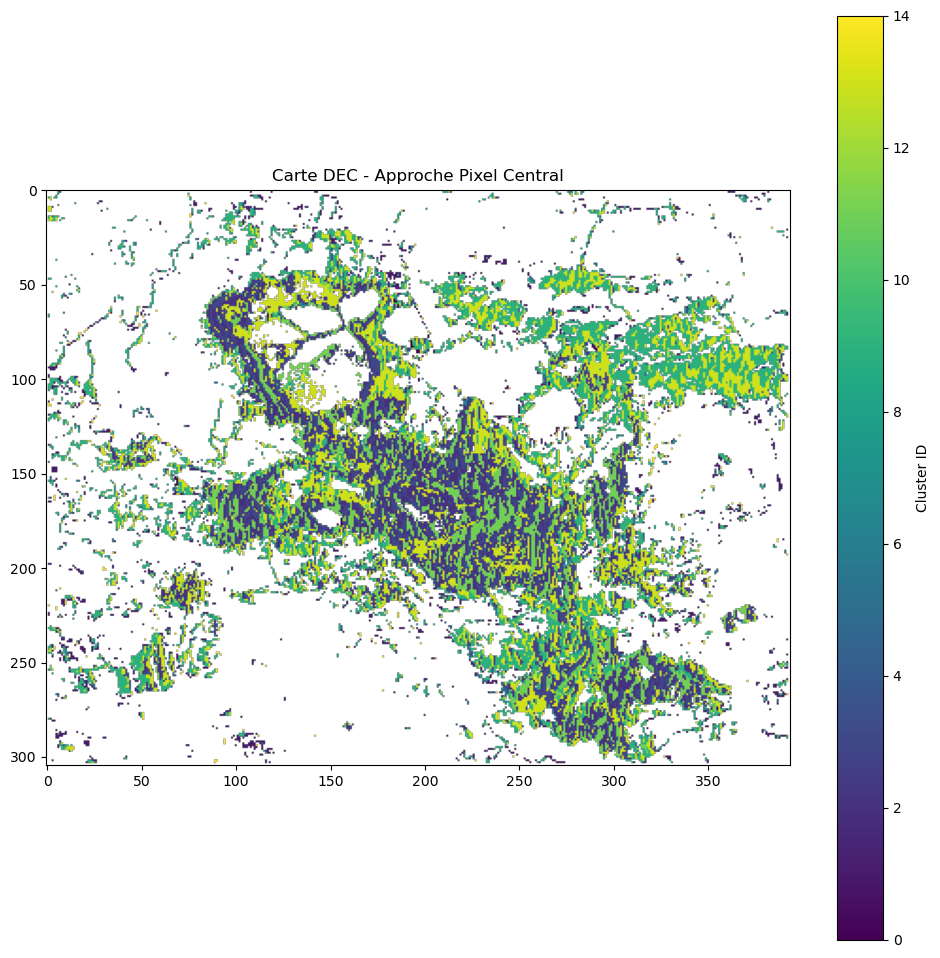

In [ ]:
final_map_soil = generate_map_batch_central(model_final_soil, img_scaled_soil_complete.T.reshape(-1,m,n), soil_mask_2d)

# On masque les valeurs -1 pour l'affichage
display_map = np.ma.masked_where(final_map_soil == -1, final_map_soil)

plt.figure(figsize=(12, 12))
plt.imshow(display_map, cmap='viridis') # Ou 'terrain' pour la végétation
plt.colorbar(label='Cluster ID')
plt.title("Carte DEC - Approche Pixel Central")
plt.show()

In [ ]:
# Distribution sur la carte finale (on exclut le fond -1)
unique_map_soil, counts_map_soil = np.unique(final_map_soil[final_map_soil != -1], return_counts=True)
print("Distribution Carte :", dict(zip(unique_map_soil, counts_map_soil)))

Distribution Carte : {np.int8(0): np.int64(66), np.int8(1): np.int64(1992), np.int8(2): np.int64(5854), np.int8(3): np.int64(6058), np.int8(4): np.int64(253), np.int8(5): np.int64(644), np.int8(6): np.int64(215), np.int8(7): np.int64(7), np.int8(8): np.int64(845), np.int8(9): np.int64(9780), np.int8(10): np.int64(72), np.int8(11): np.int64(5246), np.int8(12): np.int64(15), np.int8(13): np.int64(9304), np.int8(14): np.int64(335)}


In [ ]:
labels_soil = Silhouette(img_scaled_soil_complete.reshape(m,n,l), final_map_soil, optimal_k_soil, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 15 : -0.146


<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
5.3. Other

In [ ]:
# 1. Conversion explicite en Tenseurs PyTorch
# .float() est nécessaire pour la convolution plus bas
img_other_torch = torch.from_numpy(img_scaled_other_complete.reshape(n,m,l).T).float()
mask_other_torch = torch.from_numpy(other_mask_2d).float()

# 1. Instanciation du Dataset
other_ds = DeepClusteringDataset(
    img_tensor=img_other_torch, 
    mask_tensor=mask_other_torch, 
    patch_size=PATCH_SIZE, 
    stride=STRIDE, 
    min_valid_ratio=MIN_VALID_RATIO
)

# 2. Création du DataLoader compatible avec le script d'entraînement
dataloader_other = DataLoader(
    other_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Mélange les patchs à chaque époque
    num_workers=0,     # Accélère le chargement via CPU multi-threading
    pin_memory=True,    # Accélère le transfert vers le GPU
    persistent_workers = False
)

In [ ]:
CHANNELS = l # Nombre de bandes (ex: 3 pour RGB, 4 pour RGB-NIR)
ae_other = ConvAutoencoder_forDC(in_channels=CHANNELS, latent_dim=LATENT_DIM)

In [ ]:
model_final_other = train_model(
    ae_other, 
    dataloader_other, 
    N_EPOCHS_AE,           # Phase de reconstruction
    N_EPOCHS_CLUSTERING,   # Phase de raffinement des clusters
    optimal_k_other,
    LATENT_DIM
)

# Sauvegarde du modèle pour ne pas perdre l'apprentissage
torch.save(model_final_other.state_dict(), "dec_model_other.pth")
print("Modèle entraîné et sauvegardé !")

Phase 1 : Pré-entraînement de l'Autoencodeur...
Epoch 1 - MSE Loss: 0.042946
Epoch 2 - MSE Loss: 0.025709
Epoch 3 - MSE Loss: 0.014508
Epoch 4 - MSE Loss: 0.008645
Epoch 5 - MSE Loss: 0.006282
Epoch 6 - MSE Loss: 0.005495
Epoch 7 - MSE Loss: 0.005480
Epoch 8 - MSE Loss: 0.005444
Epoch 9 - MSE Loss: 0.004827
Epoch 10 - MSE Loss: 0.004580
Epoch 11 - MSE Loss: 0.004436
Epoch 12 - MSE Loss: 0.004203
Epoch 13 - MSE Loss: 0.004124
Epoch 14 - MSE Loss: 0.003941
Epoch 15 - MSE Loss: 0.003796
Epoch 16 - MSE Loss: 0.003890
Epoch 17 - MSE Loss: 0.004027
Epoch 18 - MSE Loss: 0.004046
Epoch 19 - MSE Loss: 0.003874
Epoch 20 - MSE Loss: 0.003679
Epoch 21 - MSE Loss: 0.003819
Epoch 22 - MSE Loss: 0.003714
Epoch 23 - MSE Loss: 0.003793
Epoch 24 - MSE Loss: 0.003935
Epoch 25 - MSE Loss: 0.003975

Phase 2 : Initialisation des clusters avec K-Means...


c:\Users\arman\anaconda3\envs\geo_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Répartition initiale K-Means : [ 61 169  99  51 103  86]

Phase 3 : Raffinement par divergence KL...
Epoch 1 - KL: -0.000006 | MSE: 0.003853
Epoch 2 - KL: -0.000006 | MSE: 0.003853
Epoch 3 - KL: -0.000006 | MSE: 0.003853
Modèle entraîné et sauvegardé !


Extraction des caractéristiques latentes...
Calcul du t-SNE (cela peut prendre une minute)...


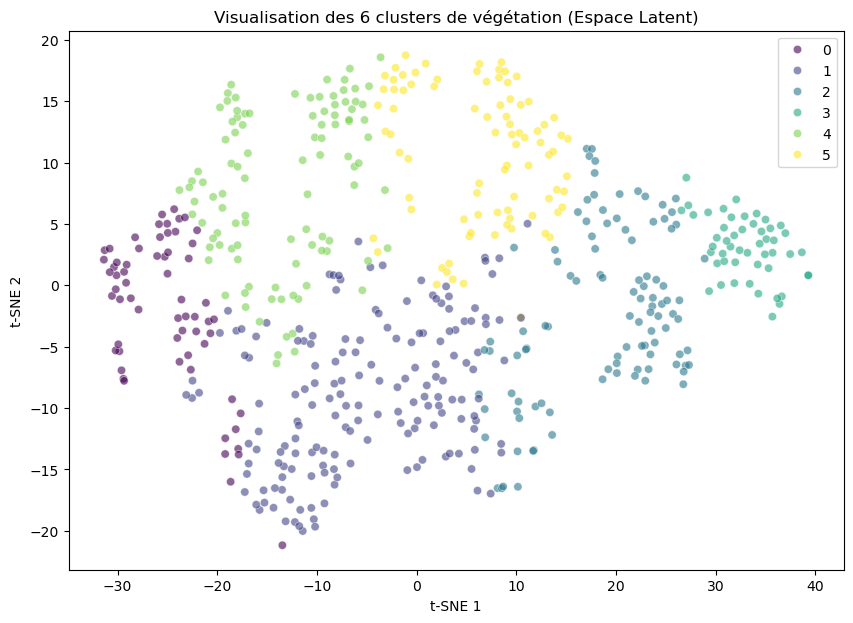

In [ ]:
# Utilisation :
plot_clusters(model_final_other, dataloader_other)

Calcul des coordonnées valides...
Nombre de patchs à traiter : 5382


100%|██████████| 11/11 [00:01<00:00,  6.31it/s]


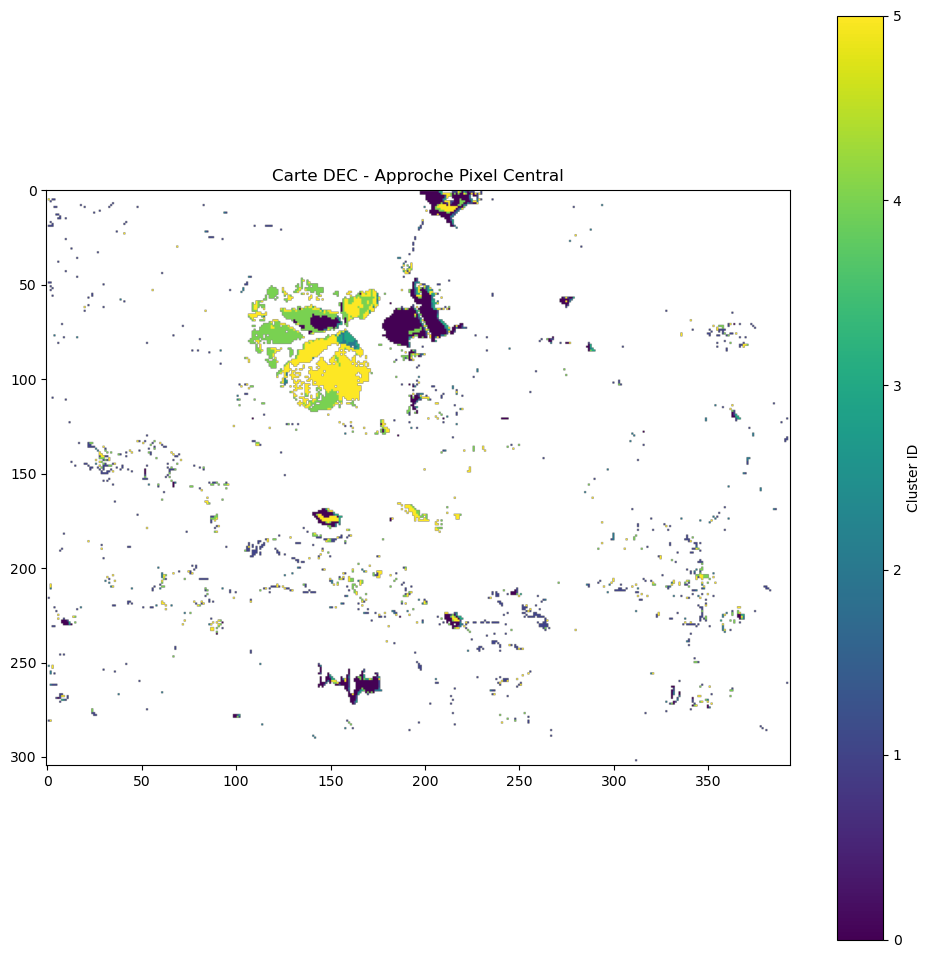

In [ ]:
final_map_other = generate_map_batch_central(model_final_other, img_scaled_other_complete.T.reshape(-1,m,n), other_mask_2d)

# On masque les valeurs -1 pour l'affichage
display_map = np.ma.masked_where(final_map_other == -1, final_map_other)

plt.figure(figsize=(12, 12))
plt.imshow(display_map, cmap='viridis') # Ou 'terrain' pour la végétation
plt.colorbar(label='Cluster ID')
plt.title("Carte DEC - Approche Pixel Central")
plt.show()

In [ ]:
labels_other = Silhouette(img_scaled_other_complete.reshape(m,n,l), final_map_other, optimal_k_other, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 6 : 0.011
